In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("Библиотеки загружены")

Библиотеки загружены


In [55]:
df = pd.read_csv('processed_titanic-checkpoint.csv')
print(f"Датасет: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Датасет: 891 строк, 12 столбцов


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [56]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
df['Embarked'] = df['Embarked'].fillna('S')
df['Cabin'] = df['Cabin'].fillna('Unknown')

le_sex = LabelEncoder()
le_embarked = LabelEncoder()
le_cabin = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])  # male=1, female=0
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])  # S=?, C=?, Q=?
df['Cabin'] = le_cabin.fit_transform(df['Cabin'])

df = df.drop(['Name', 'Ticket', 'PassengerId'], axis=1)

print("Данные подготовлены!")
print(f"Столбцы: {df.columns.tolist()}")
df.head()

Данные подготовлены!
Столбцы: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,7.2500,147,2
1,1,1,0,38.0,1,0,71.2833,81,0
2,1,3,0,26.0,0,0,7.9250,147,2
3,1,1,0,35.0,1,0,53.1000,55,2
4,0,3,1,35.0,0,0,8.0500,147,2


ЗАДАЧА РЕГРЕССИИ - предсказание возраста пассажиров
Обучающая выборка: 712 объектов
Тестовая выборка: 179 объектов

РЕЗУЛЬТАТЫ РЕГРЕССИИ:
MSE (среднеквадратичная ошибка): 135.1488
RMSE (корень из MSE): 11.6254 лет
R² (коэффициент детерминации): 0.2018
Качество модели: Низкое


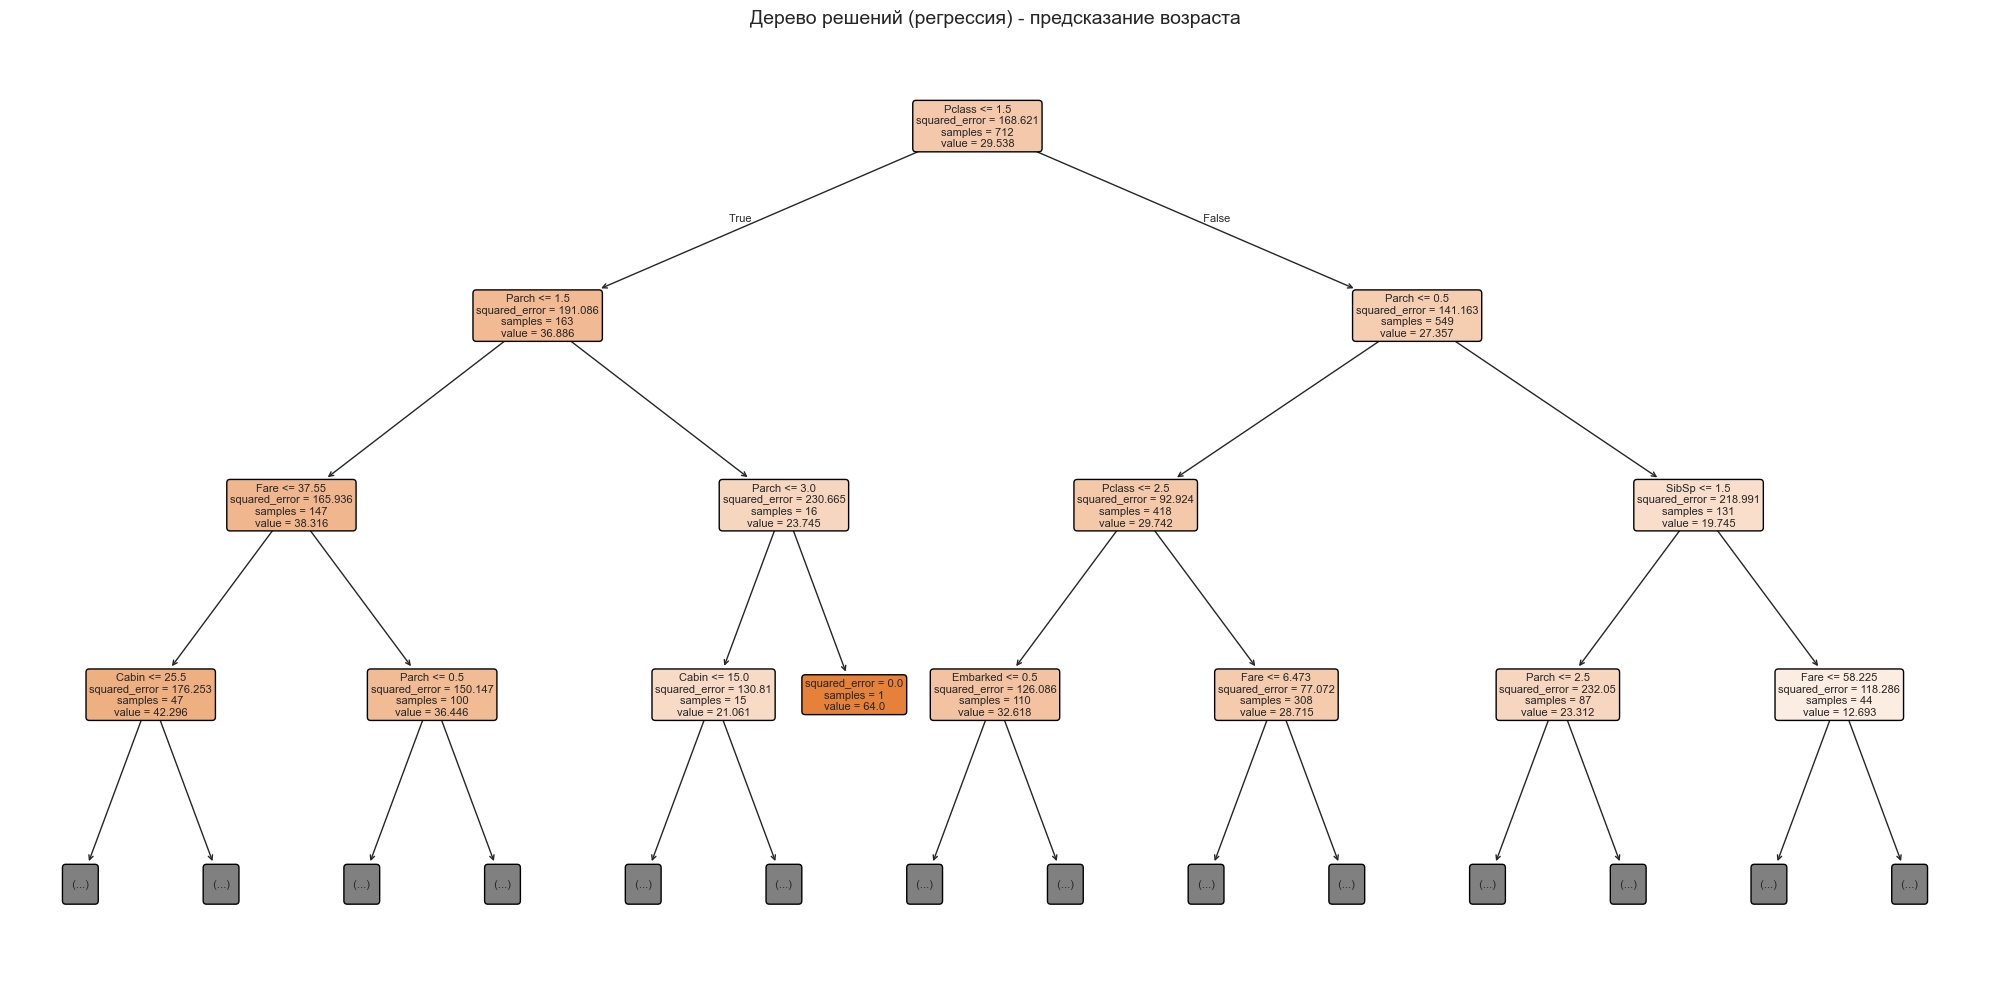

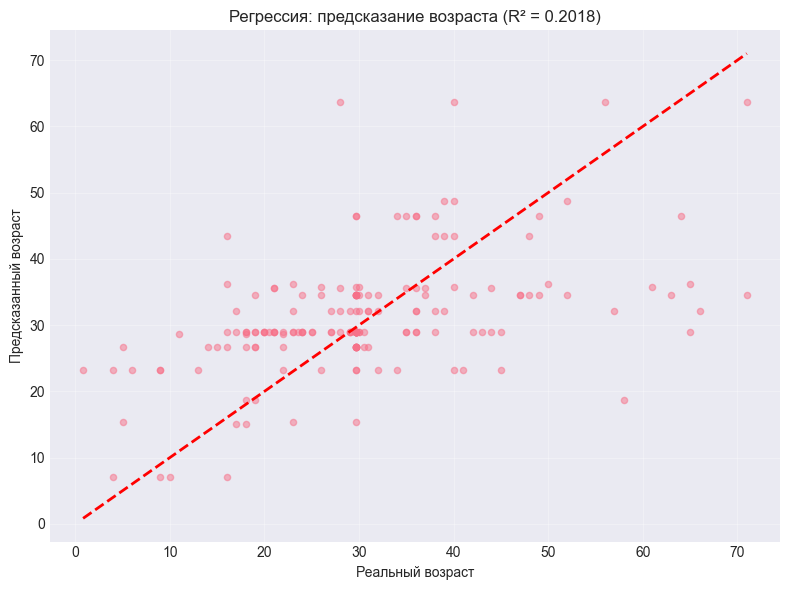

In [58]:
print("ЗАДАЧА РЕГРЕССИИ - предсказание возраста пассажиров")

X_reg = df.drop(['Age', 'Survived'], axis=1)
y_reg = df['Age']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train_reg.shape[0]} объектов")
print(f"Тестовая выборка: {X_test_reg.shape[0]} объектов")

reg_model = DecisionTreeRegressor(max_depth=5, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("\nРЕЗУЛЬТАТЫ РЕГРЕССИИ:")
print(f"MSE (среднеквадратичная ошибка): {mse:.4f}")
print(f"RMSE (корень из MSE): {rmse:.4f} лет")
print(f"R² (коэффициент детерминации): {r2:.4f}")

if r2 > 0.5:
    print("Качество модели: Хорошее")
elif r2 > 0.3:
    print("Качество модели: Среднее")
else:
    print("Качество модели: Низкое")

plt.figure(figsize=(20, 10))
plot_tree(reg_model, feature_names=X_reg.columns, filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Дерево решений (регрессия) - предсказание возраста", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, s=20)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel("Реальный возраст")
plt.ylabel("Предсказанный возраст")
plt.title(f"Регрессия: предсказание возраста (R² = {r2:.4f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ЗАДАЧА КЛАССИФИКАЦИИ - предсказание выживания пассажиров
Обучающая выборка: 712 объектов
Тестовая выборка: 179 объектов
Распределение классов в обучении:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:
Accuracy (точность): 0.7709
Precision (точность предсказания выживших): 0.7917
Recall (полнота обнаружения выживших): 0.5507
F1-score: 0.6496


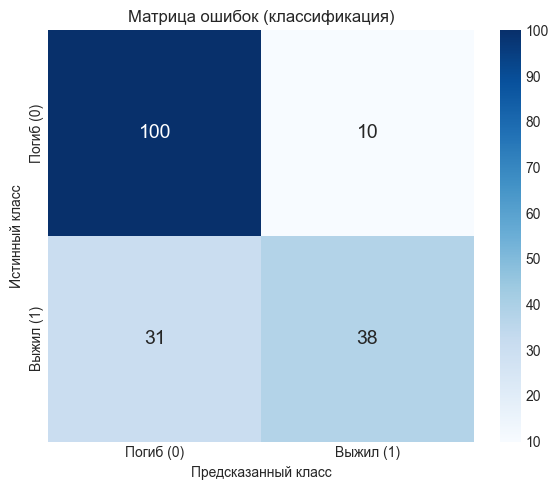

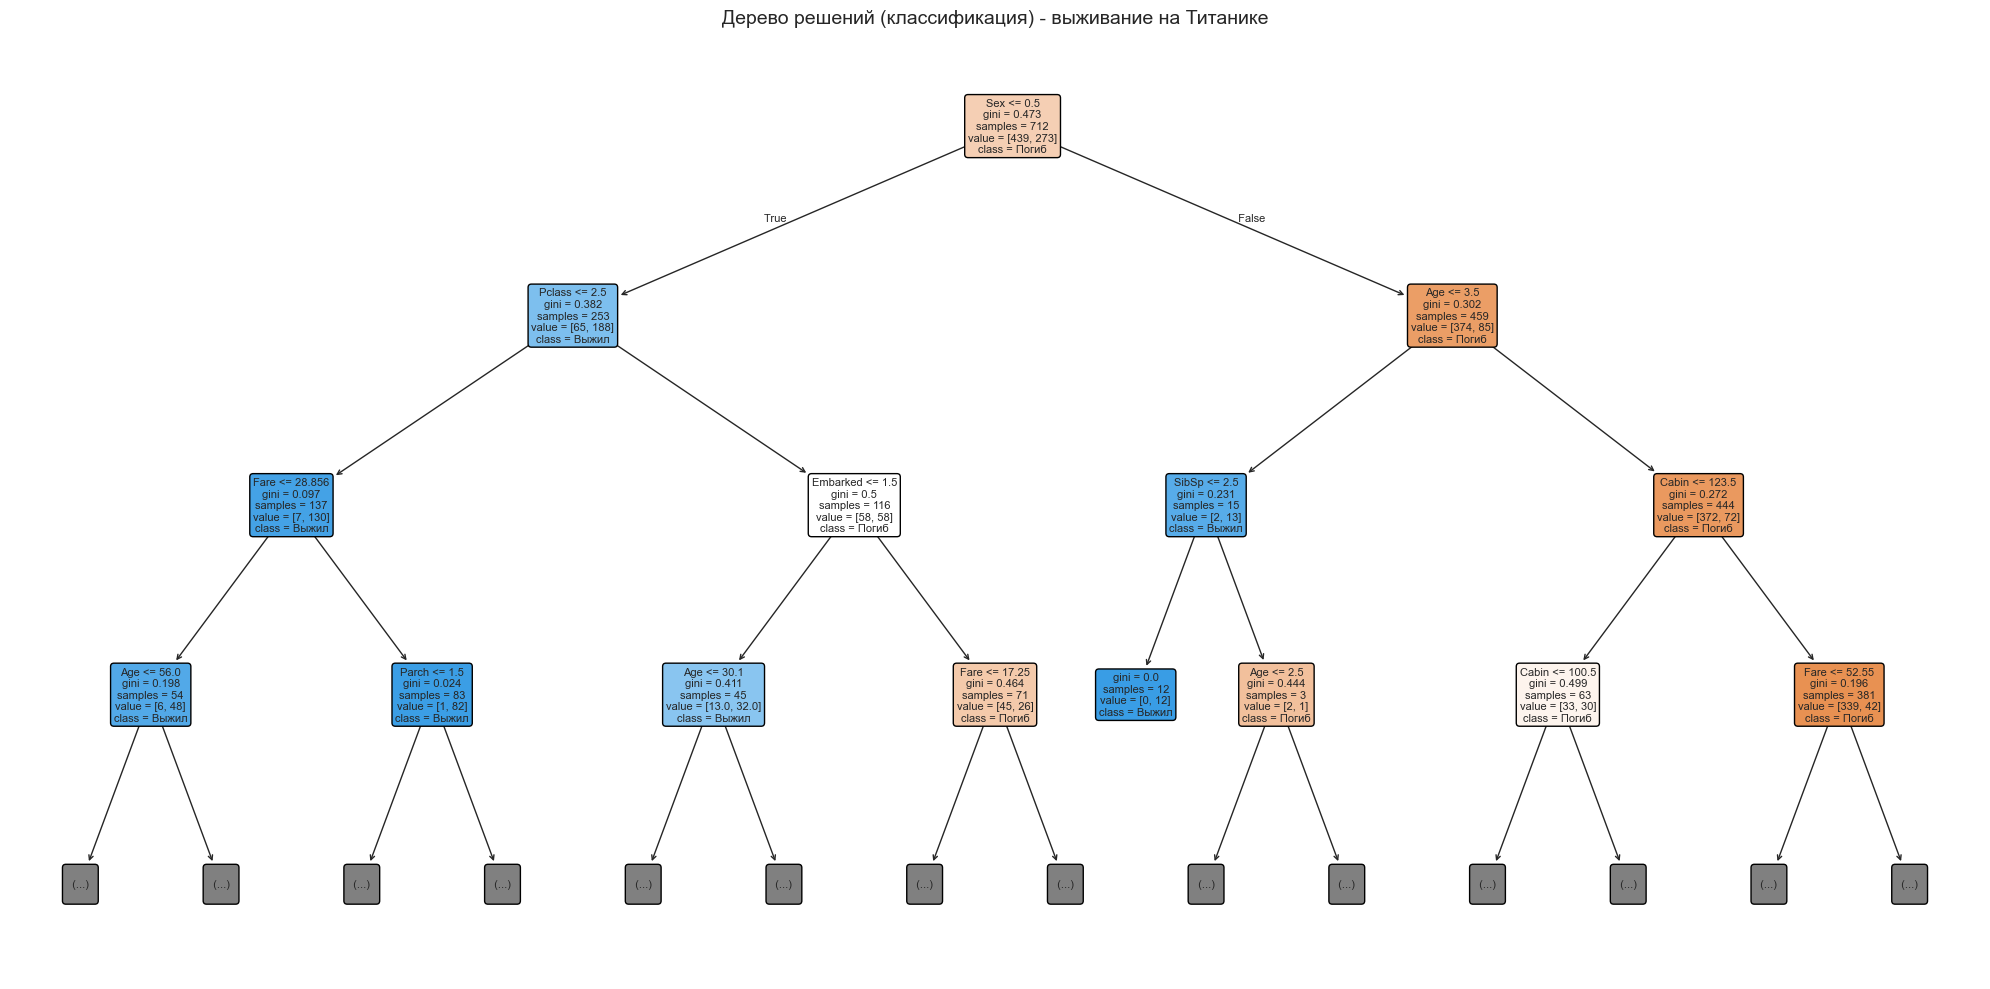

In [59]:
print("ЗАДАЧА КЛАССИФИКАЦИИ - предсказание выживания пассажиров")

X_clf = df.drop('Survived', axis=1)
y_clf = df['Survived']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Обучающая выборка: {X_train_clf.shape[0]} объектов")
print(f"Тестовая выборка: {X_test_clf.shape[0]} объектов")
print(f"Распределение классов в обучении:\n{y_train_clf.value_counts(normalize=True)}")

clf_model = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_model.fit(X_train_clf, y_train_clf)

y_pred_clf = clf_model.predict(X_test_clf)
y_proba_clf = clf_model.predict_proba(X_test_clf)[:, 1]

print("\nРЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:")
print(f"Accuracy (точность): {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"Precision (точность предсказания выживших): {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"Recall (полнота обнаружения выживших): {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"F1-score: {f1_score(y_test_clf, y_pred_clf):.4f}")

cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Погиб (0)', 'Выжил (1)'],
            yticklabels=['Погиб (0)', 'Выжил (1)'],
            annot_kws={'size': 14})
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (классификация)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(clf_model, feature_names=X_clf.columns, class_names=['Погиб', 'Выжил'], 
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Дерево решений (классификация) - выживание на Титанике", fontsize=14)
plt.tight_layout()
plt.show()

ROC-КРИВАЯ


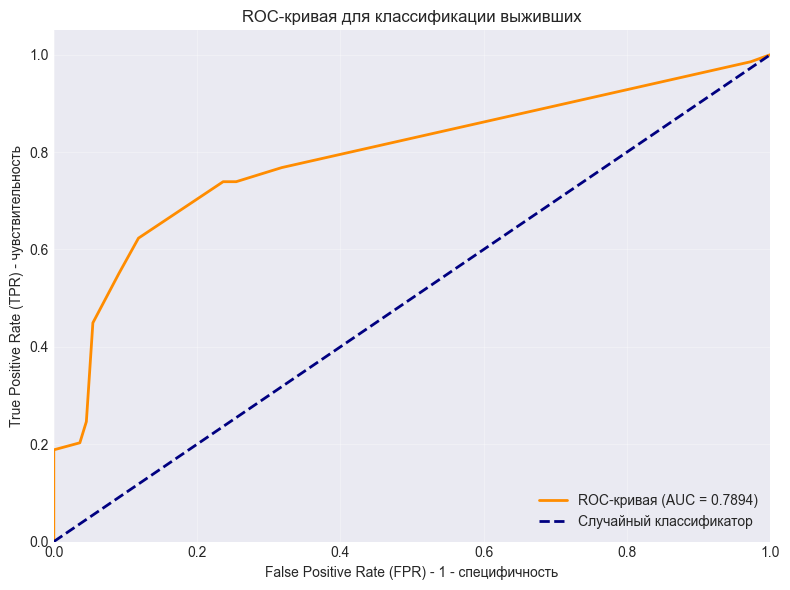

Площадь под ROC-кривой (AUC) = 0.7894
Качество модели: Среднее


In [61]:
print("ROC-КРИВАЯ")

fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba_clf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR) - 1 - специфичность')
plt.ylabel('True Positive Rate (TPR) - чувствительность')
plt.title('ROC-кривая для классификации выживших')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Площадь под ROC-кривой (AUC) = {roc_auc:.4f}")

if roc_auc >= 0.9:
    print("Качество модели: Отличное")
elif roc_auc >= 0.8:
    print("Качество модели: Хорошее")
elif roc_auc >= 0.7:
    print("Качество модели: Среднее")
elif roc_auc >= 0.6:
    print("Качество модели: Удовлетворительное")
else:
    print("Качество модели: Низкое")

АНАЛИЗ ПЕРЕОБУЧЕНИЯ


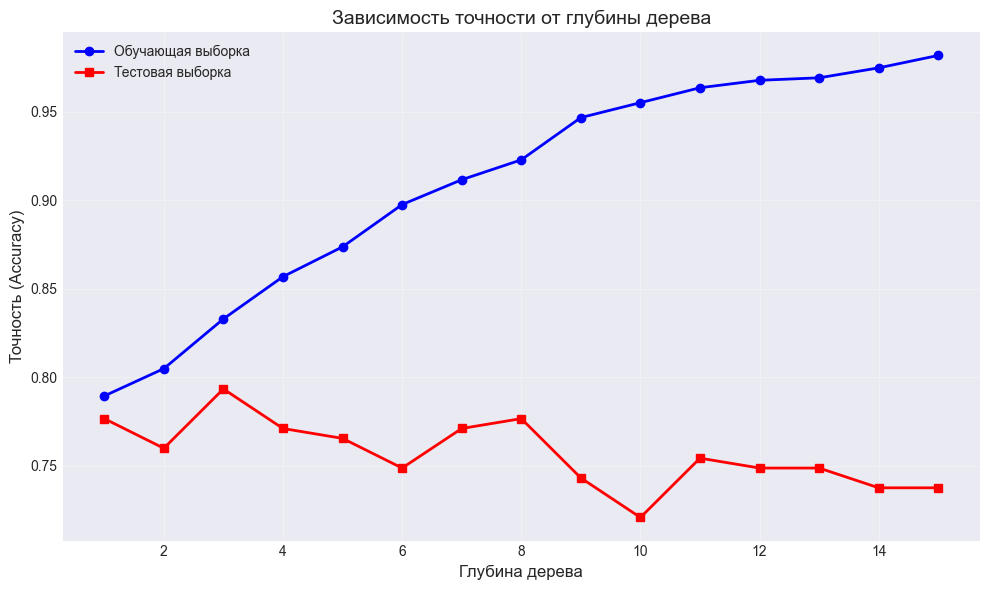

Оптимальная глубина дерева: 3
Точность на обучающей выборке: 0.8329
Точность на тестовой выборке: 0.7933
Разница (переобучение): 0.0396
Переобучение незначительное


In [64]:
print("АНАЛИЗ ПЕРЕОБУЧЕНИЯ")

depths = range(1, 16)
train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_clf, y_train_clf)
    train_scores.append(clf.score(X_train_clf, y_train_clf))
    test_scores.append(clf.score(X_test_clf, y_test_clf))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', label='Обучающая выборка', color='blue', linewidth=2, markersize=6)
plt.plot(depths, test_scores, 's-', label='Тестовая выборка', color='red', linewidth=2, markersize=6)
plt.xlabel('Глубина дерева', fontsize=12)
plt.ylabel('Точность (Accuracy)', fontsize=12)
plt.title('Зависимость точности от глубины дерева', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

optimal_depth = depths[np.argmax(test_scores)]
print(f"Оптимальная глубина дерева: {optimal_depth}")
print(f"Точность на обучающей выборке: {train_scores[optimal_depth-1]:.4f}")
print(f"Точность на тестовой выборке: {test_scores[optimal_depth-1]:.4f}")
print(f"Разница (переобучение): {train_scores[optimal_depth-1] - test_scores[optimal_depth-1]:.4f}")

if train_scores[optimal_depth-1] - test_scores[optimal_depth-1] > 0.1:
    print("Наблюдается переобучение при большей глубине")
else:
    print("Переобучение незначительное")